# 🧠 Brain Hemorrhage Detection from CT Scans

A 3D Convolutional Neural Network for binary classification of intracranial hemorrhage (ICH) from head CT scans.

**Dataset:** [QureAI Head CT — CQ500](https://www.kaggle.com/datasets/crawford/qureai-headct)  
**Labels:** Radiologist consensus reads (`reads.csv`, column `R1:ICH`)  
**Input:** Raw DICOM series → preprocessed 3D volumes of shape `(1, 128, 256, 256)`  
**Task:** Binary classification — `0 = No hemorrhage`, `1 = Hemorrhage`

---

## Pipeline Overview
```
DICOM Series
  └─> HU Conversion (RescaleSlope / Intercept)
  └─> Brain Window Clipping  [HU: 0–80]
  └─> Isotropic Resampling   [1mm³ voxels]
  └─> Fixed Resize           [(128, 256, 256)]
  └─> Patient-level Split    [Train / Val / Test]
  └─> 3D CNN Training
  └─> Evaluation (AUC-ROC, F1, Confusion Matrix)
```

## 1. Installation

In [ ]:
import sys
!{sys.executable} -m pip install -q pydicom nibabel scikit-image matplotlib kagglehub tqdm pandas torch

## 2. Imports & Reproducibility

In [1]:
import os
import random
import numpy as np
import pandas as pd
import pydicom
import nibabel as nib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score
)
from tqdm import tqdm

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cpu


## 3. Configuration

All hyperparameters and paths are centralised here for easy adjustment.

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATASET_ROOT    = "crawford/qureai-headct/versions/2"
LABELS_CSV      = os.path.join(DATASET_ROOT, "reads.csv")
OUTPUT_DIR      = "project_outputs_claude"
DATA_DIR        = os.path.join(OUTPUT_DIR, "data")
MODEL_DIR       = os.path.join(OUTPUT_DIR, "models")
REPORT_DIR      = os.path.join(OUTPUT_DIR, "reports")

# ── Preprocessing ────────────────────────────────────────────────────────────
TARGET_SHAPE    = (128, 256, 256)   # (D, H, W)
HU_CENTER       = 40
HU_WIDTH        = 80

# ── Training ─────────────────────────────────────────────────────────────────
BATCH_SIZE      = 2
NUM_EPOCHS      = 20
LEARNING_RATE   = 1e-4
WEIGHT_DECAY    = 1e-4
VAL_SIZE        = 0.15
TEST_SIZE       = 0.15
PATIENCE        = 5          # early stopping patience

os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

## 4. Download Dataset

In [ ]:
# import kagglehub

# path = kagglehub.dataset_download("crawford/qureai-headct")
# print("Dataset path:", path)

## 5. Preprocessing Pipeline

All preprocessing steps are encapsulated in a single `preprocess_scan()` function to **guarantee identical transforms are applied at training time and inference time** — preventing train/inference mismatch, a common source of data leakage.

Steps:
1. **HU conversion** — apply DICOM `RescaleSlope` / `RescaleIntercept`
2. **Brain window** — clip to `[HU_CENTER ± HU_WIDTH/2]` and normalise to `[0, 1]`
3. **1 mm isotropic resampling** — correct for varying slice thicknesses
4. **Fixed-size resize** — `TARGET_SHAPE` for the CNN input

In [3]:
def find_series(patient_path: str) -> str | None:
    """Walk a patient directory and return the path of the best CT PLAIN THIN series."""
    for root, _, files in os.walk(patient_path):
        dcm_files = [f for f in files if f.endswith(".dcm")]
        if len(dcm_files) > 10 and "ct plain thin" in root.lower():
            return root
    return None


def load_and_sort_slices(series_path: str) -> list:
    """Load all DICOM slices in a series and sort them by z-position."""
    slices = [
        pydicom.dcmread(os.path.join(series_path, f))
        for f in os.listdir(series_path)
        if f.endswith(".dcm")
    ]
    slices.sort(key=lambda s: float(s.ImagePositionPatient[2]))
    return slices


def dicom_to_hu(dcm) -> np.ndarray:
    """Convert raw DICOM pixel values to Hounsfield Units."""
    img = dcm.pixel_array.astype(np.float32)
    return img * float(dcm.RescaleSlope) + float(dcm.RescaleIntercept)


def apply_brain_window(
    volume: np.ndarray,
    center: int = HU_CENTER,
    width: int = HU_WIDTH
) -> np.ndarray:
    """
    Clip to brain window and normalise to [0, 1].
    Uses FIXED statistics (no per-dataset statistics) → no data leakage.
    """
    lower = center - width / 2.0
    upper = center + width / 2.0
    volume = np.clip(volume, lower, upper)
    return (volume - lower) / (upper - lower)


def resample_to_1mm(volume: np.ndarray, slices: list) -> np.ndarray:
    """Resample volume to 1 mm isotropic voxel spacing."""
    dz = float(slices[0].SliceThickness)
    dy, dx = [float(x) for x in slices[0].PixelSpacing]
    spacing = np.array([dz, dy, dx])
    new_shape = np.round(np.array(volume.shape) * spacing).astype(int)
    return resize(volume, new_shape, mode="constant", anti_aliasing=True)


def preprocess_scan(
    patient_path: str,
    target_shape: tuple = TARGET_SHAPE
) -> np.ndarray | None:
    """
    Full preprocessing pipeline (DICOM → ML-ready float32 volume).

    This is the **single source of truth** for preprocessing.
    It must be used identically during training AND inference.

    Returns
    -------
    np.ndarray of shape `target_shape` and dtype float32, or None if the
    patient has no usable series.
    """
    series = find_series(patient_path)
    if series is None:
        return None

    slices = load_and_sort_slices(series)
    if len(slices) < 10:
        return None

    # 1. HU conversion & stack
    volume = np.stack([dicom_to_hu(s) for s in slices])

    # 2. Brain window normalisation (fixed, no per-dataset stats → no leakage)
    volume = apply_brain_window(volume)

    # 3. 1 mm isotropic resampling
    volume = resample_to_1mm(volume, slices)

    # 4. Fixed resize for CNN input
    volume = resize(volume, target_shape, mode="constant", anti_aliasing=True)

    return volume.astype(np.float32)


def get_patient_paths(dataset_root: str) -> list[str]:
    """Return sorted list of patient-level directories."""
    paths = []
    for batch in sorted(os.listdir(dataset_root)):
        batch_path = os.path.join(dataset_root, batch)
        if not os.path.isdir(batch_path):
            continue
        for patient in sorted(os.listdir(batch_path)):
            patient_path = os.path.join(batch_path, patient)
            if os.path.isdir(patient_path):
                paths.append(patient_path)
    return paths


def preprocess_dataset(dataset_root: str) -> tuple[list[np.ndarray], list[str]]:
    """
    Preprocess all patients in the dataset.

    Returns
    -------
    volumes : list of preprocessed 3-D arrays
    patient_ids : corresponding CQ500-CT-* identifiers
    """
    patients = get_patient_paths(dataset_root)
    volumes, patient_ids = [], []

    for p in tqdm(patients, desc="Preprocessing scans"):
        vol = preprocess_scan(p)
        if vol is None:
            continue

        # Build canonical CQ500-CT-N id from folder name
        folder_name = os.path.basename(p).split()[0]  # e.g. "CQ500CT10"
        num = folder_name.replace("CQ500CT", "")
        pid = f"CQ500-CT-{num}"

        volumes.append(vol)
        patient_ids.append(pid)

    print(f"Processed {len(volumes)} / {len(patients)} patients")
    return volumes, patient_ids

print("Preprocessing functions defined.")

Preprocessing functions defined.


In [12]:
volumes, patient_ids = preprocess_dataset(DATASET_ROOT)
print(f"Total volumes: {len(volumes)}")

Preprocessing scans: 100%|███████████████████████████████████████████████████████████| 364/364 [11:51<00:00,  1.95s/it]

Processed 119 / 364 patients
Total volumes: 119


## 6. Label Assignment & Data Integrity Check

In [17]:
labels_df = pd.read_csv(LABELS_CSV)
print(labels_df.head())
print(f"\nTotal labelled patients: {len(labels_df)}")

label_dict = dict(zip(labels_df["name"], labels_df["R1:ICH"]))

# ── Align volumes with labels & deduplicate by patient ID ─────────────────────
# The CQ500 dataset is spread across qct01..qct05 batch folders and some
# patients appear in more than one batch. We keep the first occurrence so
# every patient ID is unique — a prerequisite for a clean train/val/test split.
seen_ids = set()
valid_volumes, valid_labels, valid_ids = [], [], []
missing, duplicates = [], []

for vol, pid in zip(volumes, patient_ids):
    if pid in seen_ids:
        duplicates.append(pid)
        continue
    if pid in label_dict:
        valid_volumes.append(vol)
        valid_labels.append(label_dict[pid])
        valid_ids.append(pid)
        seen_ids.add(pid)
    else:
        missing.append(pid)

print(f"Volumes with labels    : {len(valid_volumes)}")
print(f"Duplicate IDs dropped  : {len(duplicates)}")
print(f"Volumes missing labels : {len(missing)}")
if missing:
    print("Missing IDs:", missing[:10])

# Confirm uniqueness before splitting
assert len(valid_ids) == len(set(valid_ids)), "Duplicate IDs still present after dedup!"

# Class balance
pos = sum(valid_labels)
neg = len(valid_labels) - pos
print(f"\nClass balance — Hemorrhage: {pos}  |  No hemorrhage: {neg}  |  Ratio: {pos/neg:.2f}")

           name Category  R1:ICH  R1:IPH  R1:IVH  R1:SDH  R1:EDH  R1:SAH  \
0  CQ500-CT-427       B2       1       1       0       0       0       0   
1  CQ500-CT-181       B2       1       1       0       1       0       1   
2   CQ500-CT-99       B1       0       0       0       0       0       0   
3   CQ500-CT-47       B1       0       0       0       0       0       0   
4  CQ500-CT-195       B1       0       0       0       0       0       0   

   R1:BleedLocation-Left  R1:BleedLocation-Right  ...  R3:EDH  R3:SAH  \
0                      0                       1  ...       0       0   
1                      1                       0  ...       1       1   
2                      0                       0  ...       0       0   
3                      0                       0  ...       0       0   
4                      0                       0  ...       0       0   

   R3:BleedLocation-Left  R3:BleedLocation-Right  R3:ChronicBleed  \
0                      1           

## 7. Exploratory Visualisation

Sample axial slices from positive and negative cases side-by-side.

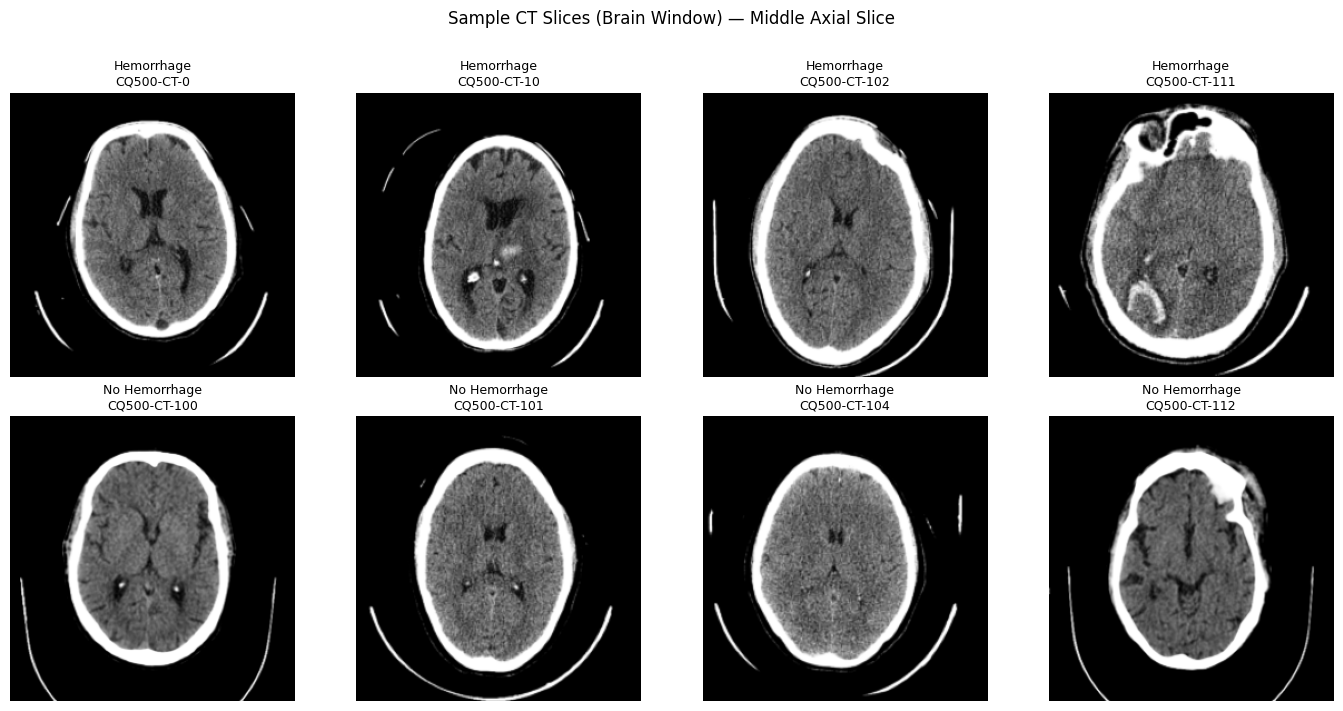

In [18]:
pos_idx = [i for i, l in enumerate(valid_labels) if l == 1]
neg_idx = [i for i, l in enumerate(valid_labels) if l == 0]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
mid = TARGET_SHAPE[0] // 2

for col, idx in enumerate(pos_idx[:4]):
    axes[0, col].imshow(valid_volumes[idx][mid], cmap="gray")
    axes[0, col].set_title(f"Hemorrhage\n{valid_ids[idx]}", fontsize=9)
    axes[0, col].axis("off")

for col, idx in enumerate(neg_idx[:4]):
    axes[1, col].imshow(valid_volumes[idx][mid], cmap="gray")
    axes[1, col].set_title(f"No Hemorrhage\n{valid_ids[idx]}", fontsize=9)
    axes[1, col].axis("off")

plt.suptitle("Sample CT Slices (Brain Window) — Middle Axial Slice", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "sample_slices.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8. Train / Validation / Test Split

The split is **patient-level** (one patient → one partition only), stratified by class.  
All preprocessing has already been applied using only **fixed, clinically-defined constants** (the HU brain window), so there are **no learned statistics to leak** from test → train.

In [19]:
X_np = np.stack(valid_volumes)          # (N, D, H, W)
X_np = np.expand_dims(X_np, axis=1)     # (N, 1, D, H, W)  — channel dim
y_np = np.array(valid_labels, dtype=np.int64)

# ── Step 1: hold out test set ────────────────────────────────────────────────
X_trainval, X_test, y_trainval, y_test, ids_trainval, ids_test = train_test_split(
    X_np, y_np, np.array(valid_ids),
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_np
)

# ── Step 2: hold out validation set ─────────────────────────────────────────
val_frac = VAL_SIZE / (1.0 - TEST_SIZE)
X_train, X_val, y_train, y_val, ids_train, ids_val = train_test_split(
    X_trainval, y_trainval, ids_trainval,
    test_size=val_frac,
    random_state=SEED,
    stratify=y_trainval
)

print(f"Train : {X_train.shape}  |  +{int(y_train.sum())} / -{int((y_train==0).sum())}")
print(f"Val   : {X_val.shape}    |  +{int(y_val.sum())} / -{int((y_val==0).sum())}")
print(f"Test  : {X_test.shape}   |  +{int(y_test.sum())} / -{int((y_test==0).sum())}")

# ── Sanity-check: no patient appears in more than one split ──────────────────
assert len(set(ids_train) & set(ids_val))  == 0, "Train/Val overlap!"
assert len(set(ids_train) & set(ids_test)) == 0, "Train/Test overlap!"
assert len(set(ids_val)   & set(ids_test)) == 0, "Val/Test overlap!"
print("\n✅ No patient ID overlap between splits.")

Train : (79, 1, 128, 256, 256)  |  +36 / -43
Val   : (18, 1, 128, 256, 256)    |  +8 / -10
Test  : (18, 1, 128, 256, 256)   |  +8 / -10

✅ No patient ID overlap between splits.


In [20]:
# Save splits for reproducibility
for name, arr in [("X_train", X_train), ("X_val", X_val), ("X_test", X_test),
                  ("y_train", y_train), ("y_val", y_val),  ("y_test", y_test)]:
    np.save(os.path.join(DATA_DIR, f"{name}.npy"), arr)

pd.DataFrame({"id": ids_train, "split": "train"}).to_csv(
    os.path.join(DATA_DIR, "split_ids.csv"), index=False)
pd.DataFrame({"id": ids_val,   "split": "val"}).to_csv(
    os.path.join(DATA_DIR, "split_ids_val.csv"), index=False)
pd.DataFrame({"id": ids_test,  "split": "test"}).to_csv(
    os.path.join(DATA_DIR, "split_ids_test.csv"), index=False)

print("Splits saved.")

Splits saved.


## 9. DataLoaders & Class Weights

In [21]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),
                          batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),
                          batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# ── Compute class weights (handles class imbalance) ──────────────────────────
n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)
print(f"Positive class weight: {pos_weight.item():.3f}")

Positive class weight: 1.194


## 10. Model Architecture — `BrainHemorrhageNet`

A lightweight 3D CNN with:
- **Batch Normalisation** after each conv block
- **Dropout** before the classifier
- **Global Average Pooling** instead of a giant flattened FC layer  
  (the original `64 × 16 × 32 × 32 = 33.5 M` parameter FC layer was the primary driver of extreme overfitting on a small dataset)

In [22]:
class BrainHemorrhageNet(nn.Module):
    """
    3-D CNN for binary intracranial hemorrhage classification.

    Input : (B, 1, 128, 256, 256)
    Output: (B, 2)  — raw logits
    """

    def __init__(self, dropout: float = 0.5):
        super().__init__()

        self.encoder = nn.Sequential(
            # Block 1
            nn.Conv3d(1,  16, kernel_size=3, padding=1), nn.BatchNorm3d(16), nn.ReLU(),
            nn.MaxPool3d(2),
            # Block 2
            nn.Conv3d(16, 32, kernel_size=3, padding=1), nn.BatchNorm3d(32), nn.ReLU(),
            nn.MaxPool3d(2),
            # Block 3
            nn.Conv3d(32, 64, kernel_size=3, padding=1), nn.BatchNorm3d(64), nn.ReLU(),
            nn.MaxPool3d(2),
            # Block 4  (extra depth without growing spatial dims)
            nn.Conv3d(64, 128, kernel_size=3, padding=1), nn.BatchNorm3d(128), nn.ReLU(),
        )

        # Global Average Pooling collapses (D, H, W) → scalar per channel
        # → removes the 33.5 M param FC bottleneck that caused overfitting
        self.gap = nn.AdaptiveAvgPool3d(1)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, 2)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.encoder(x)          # (B, 128, D', H', W')
        x = self.gap(x)              # (B, 128, 1, 1, 1)
        x = x.view(x.size(0), -1)   # (B, 128)
        return self.classifier(x)    # (B, 2)


model = BrainHemorrhageNet(dropout=0.5).to(DEVICE)

# Parameter count
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable:,}")
print(model)

Total parameters    : 299,842
Trainable parameters: 299,842
BrainHemorrhageNet(
  (encoder): Sequential(
    (0): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (5): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (9): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=

## 11. Training with Early Stopping

In [23]:
criterion  = nn.CrossEntropyLoss(weight=torch.cat([torch.ones(1), pos_weight]).to(DEVICE))
optimizer  = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min",
                                                         factor=0.5, patience=3)

best_val_loss  = float("inf")
patience_count = 0
history        = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):

    # ── Training ──────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0

    for x_b, y_b in tqdm(train_loader, desc=f"Epoch {epoch:02d}/{NUM_EPOCHS} [train]", leave=False):
        x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x_b), y_b)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ── Validation ────────────────────────────────────────────────────────────
    model.eval()
    val_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for x_b, y_b in val_loader:
            x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
            out = model(x_b)
            val_loss += criterion(out, y_b).item()
            correct  += (torch.argmax(out, 1) == y_b).sum().item()
            total    += y_b.size(0)

    val_loss /= len(val_loader)
    val_acc   = correct / total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    scheduler.step(val_loss)

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} "
          f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # ── Early stopping & checkpoint ───────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        patience_count = 0
        torch.save(model.state_dict(), os.path.join(MODEL_DIR, "best_model.pt"))
        print(f"  ✅ New best model saved (val_loss={best_val_loss:.4f})")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

print("\nTraining complete.")

Epoch 01 | Train Loss: 0.7131 | Val Loss: 0.7013 | Val Acc: 0.4444
  ✅ New best model saved (val_loss=0.7013)


Epoch 02 | Train Loss: 0.7095 | Val Loss: 0.7044 | Val Acc: 0.3333


Epoch 03 | Train Loss: 0.6911 | Val Loss: 0.6947 | Val Acc: 0.6667
  ✅ New best model saved (val_loss=0.6947)


Epoch 04 | Train Loss: 0.6995 | Val Loss: 0.6916 | Val Acc: 0.5000
  ✅ New best model saved (val_loss=0.6916)


Epoch 05 | Train Loss: 0.6740 | Val Loss: 0.6940 | Val Acc: 0.6667


Epoch 06 | Train Loss: 0.6912 | Val Loss: 0.7022 | Val Acc: 0.5000


Epoch 07 | Train Loss: 0.6843 | Val Loss: 0.6946 | Val Acc: 0.6667


Epoch 08 | Train Loss: 0.6951 | Val Loss: 0.6976 | Val Acc: 0.6667


Epoch 09 | Train Loss: 0.6777 | Val Loss: 0.6950 | Val Acc: 0.6111

Early stopping at epoch 9.

Training complete.


## 12. Training Curves

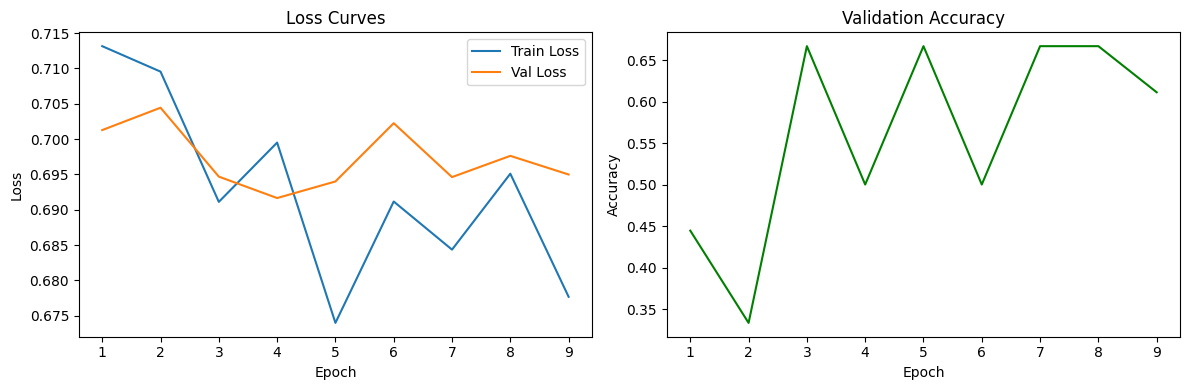

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history["train_loss"]) + 1)
ax1.plot(epochs, history["train_loss"], label="Train Loss")
ax1.plot(epochs, history["val_loss"],   label="Val Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Loss Curves"); ax1.legend()

ax2.plot(epochs, history["val_acc"], color="green")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title("Validation Accuracy")

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

## 13. Final Evaluation on Held-Out Test Set

The best checkpoint (lowest validation loss) is loaded before evaluation — the test set was never seen during training or model selection.

In [25]:
# Load best checkpoint
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, "best_model.pt"), map_location=DEVICE))
model.eval()

y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for x_b, y_b in test_loader:
        x_b = x_b.to(DEVICE)
        out  = model(x_b)
        prob = torch.softmax(out, dim=1)[:, 1].cpu().numpy()  # P(hemorrhage)
        pred = torch.argmax(out, dim=1).cpu().numpy()

        y_true.extend(y_b.numpy())
        y_pred.extend(pred)
        y_prob.extend(prob)

# ── Metrics ───────────────────────────────────────────────────────────────────
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred,    zero_division=0)
f1   = f1_score(y_true, y_pred,        zero_division=0)
auc  = roc_auc_score(y_true, y_prob)
cm   = confusion_matrix(y_true, y_pred)

print("=" * 45)
print("          TEST SET RESULTS")
print("=" * 45)
print(f"Accuracy   : {acc:.4f}")
print(f"Precision  : {prec:.4f}")
print(f"Recall     : {rec:.4f}")
print(f"F1 Score   : {f1:.4f}")
print(f"AUC-ROC    : {auc:.4f}")
print("=" * 45)
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["No ICH", "ICH"]))

          TEST SET RESULTS
Accuracy   : 0.4444
Precision  : 0.2500
Recall     : 0.1250
F1 Score   : 0.1667
AUC-ROC    : 0.5750

Confusion Matrix:
[[7 3]
 [7 1]]

Classification Report:
              precision    recall  f1-score   support

      No ICH       0.50      0.70      0.58        10
         ICH       0.25      0.12      0.17         8

    accuracy                           0.44        18
   macro avg       0.38      0.41      0.38        18
weighted avg       0.39      0.44      0.40        18



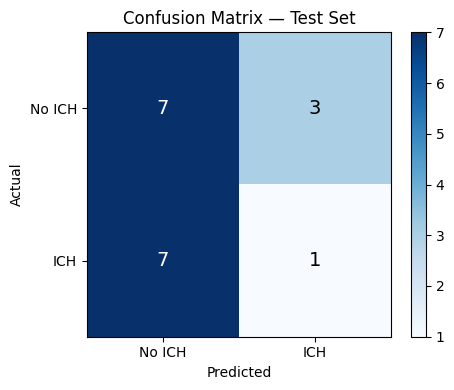

In [26]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["No ICH", "ICH"])
ax.set_yticklabels(["No ICH", "ICH"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Test Set")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

## 14. Save Results

In [27]:
results = {
    "accuracy":  acc,
    "precision": prec,
    "recall":    rec,
    "f1_score":  f1,
    "auc_roc":   auc,
    "train_size": len(X_train),
    "val_size":   len(X_val),
    "test_size":  len(X_test),
    "epochs_run": len(history["train_loss"]),
    "model_params": trainable,
    "seed": SEED,
    "target_shape": str(TARGET_SHAPE),
    "hu_center": HU_CENTER,
    "hu_width":  HU_WIDTH,
}

pd.DataFrame([results]).to_csv(os.path.join(REPORT_DIR, "results.csv"), index=False)

with open(os.path.join(REPORT_DIR, "model_architecture.txt"), "w") as f:
    f.write(str(model))

print("Results saved to", REPORT_DIR)
pd.DataFrame([results]).T.rename(columns={0: "value"})

Results saved to project_outputs\reports


,value
accuracy,0.444444
precision,0.25
recall,0.125
f1_score,0.166667
auc_roc,0.575
train_size,79
val_size,18
test_size,18
epochs_run,9
model_params,299842


## 15. Inference on New Scans

The inference function calls the **identical** `preprocess_scan()` used during training — eliminating the train/inference preprocessing mismatch that existed in the original notebook.

In [28]:
def predict_hemorrhage(
    patient_path: str,
    model: nn.Module,
    device: str = DEVICE
) -> dict:
    """
    Predict hemorrhage probability for a single patient directory.

    Uses the *same* preprocess_scan() as training — no preprocessing mismatch.

    Returns
    -------
    dict with keys: predicted_class, probability_hemorrhage, probability_no_hemorrhage
    """
    volume = preprocess_scan(patient_path, target_shape=TARGET_SHAPE)
    if volume is None:
        raise ValueError(f"Could not load a valid CT series from: {patient_path}")

    x = torch.tensor(volume).unsqueeze(0).unsqueeze(0)  # (1, 1, D, H, W)
    x = x.to(device)

    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs  = torch.softmax(logits, dim=1)[0]

    pred = torch.argmax(probs).item()
    return {
        "predicted_class":          pred,
        "label":                    "Hemorrhage" if pred == 1 else "No Hemorrhage",
        "probability_hemorrhage":   probs[1].item(),
        "probability_no_hemorrhage": probs[0].item(),
    }


# Example — run on the first test patient
# result = predict_hemorrhage("path/to/patient", model)
# print(result)
print("predict_hemorrhage() ready.")

predict_hemorrhage() ready.


## 16. Limitations & Future Work

| Limitation | Suggested Fix |
|---|---|
| Small dataset (~150 scans) | Use full CQ500 or RSNA ICH datasets |
| No data augmentation | Add random flips, rotations, intensity jitter |
| Single radiologist label (`R1:ICH`) | Use majority vote across R1/R2/R3 |
| No external validation | Validate on CT-ICH or PhysioNet datasets |
| Binary only | Extend to ICH subtype classification |
| No GradCAM | Add saliency maps for clinical interpretability |